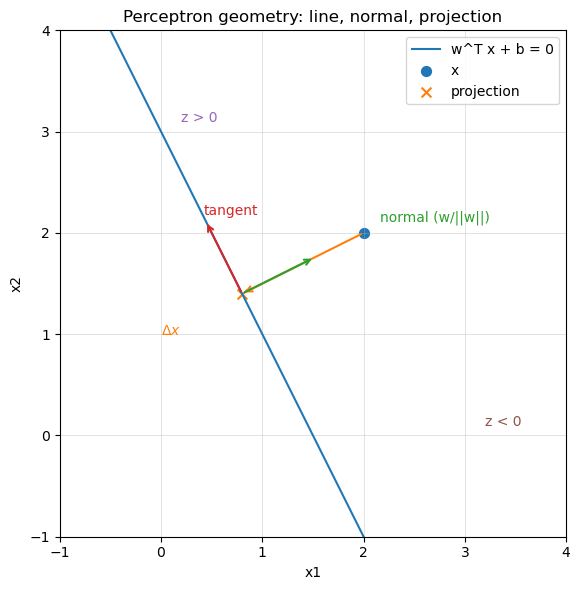

z = w^T x + b = 3.0
||Delta x|| = 1.3416 (signed distance = z/||w||)
x_proj = [0.8 1.4]
w^T x_proj + b = 0.0 (should be 0)
Delta x = [1.2 0.6] (should be parallel to w = [2. 1.])
Delta x . w = 3.0 (should have same sign as z = 3.0)
v (tangent) = [-0.4472136   0.89442719] (should be orthogonal to w = [2. 1.])
v . w = 0.0 (should be 0)
n (unit normal) = [0.89442719 0.4472136 ] (should be parallel to w = [2. 1.])
n . w = 2.23606797749979 (should have same sign as z = 3.0)
||n|| = 0.9999999999999999 (should be 1)
||w|| = 2.23606797749979
||Delta x|| = 1.3416407864998738 (should be |z|/||w|| = 1.3416407864998738)
||Delta x|| * ||w|| = 3.0 (should be |z| = 3.0)
Delta x / ||Delta x|| = [0.89442719 0.4472136 ] (should be same direction as n = [0.89442719 0.4472136 ])
W = [2. 1.], b = -3.0
normal vector = w/||w|| = [0.89442719 0.4472136 ], tangent vector = v = [-0.4472136   0.89442719]


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Data
w = np.array([2.0, 1.0])
b = -3.0
x = np.array([2.0, 2.0])

# Helper quantities
z = float(w @ x + b)
ww = float(w @ w)
delta_x = (z / ww) * w          # perpendicular vector from x to the boundary
x_proj = x - delta_x            # projection on the line
n = w / np.linalg.norm(w)       # unit normal
v = np.array([-w[1], w[0]])     # a direction vector along the line (orthogonal to w)
v = v / np.linalg.norm(v)

# Plot limits
xmin, xmax = -1.0, 4.0
ymin, ymax = -1.0, 4.0

# Decision boundary: 2*x1 + x2 - 3 = 0 -> x2 = 3 - 2*x1
xx = np.linspace(xmin, xmax, 400)
yy = 3.0 - 2.0 * xx

fig, ax = plt.subplots(figsize=(6, 6))

# Line
ax.plot(xx, yy, label="w^T x + b = 0")

# Point and projection
ax.scatter([x[0]], [x[1]], s=50, label="x")
ax.scatter([x_proj[0]], [x_proj[1]], s=50, marker="x", label="projection")

# Perpendicular vector from x to the line
ax.annotate(
    "", xy=(x_proj[0], x_proj[1]), xytext=(x[0], x[1]),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="C1")
)
ax.text(*(x - 1.5*delta_x), r"$\Delta x$", ha="right", va="top"     , color="C1")

# Normal at the projection (points to z>0 side)
scale_n = 0.8
ax.annotate(
    "", xy=(x_proj[0] + scale_n*n[0], x_proj[1] + scale_n*n[1]),
    xytext=(x_proj[0], x_proj[1]),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="C2")
)
ax.text(*(x_proj + 1.9*scale_n*n), "normal (w/||w||)", ha="left", va="bottom", color="C2")

# Tangent direction along the line
scale_v = 0.8
c = x_proj
ax.annotate(
    "", xy=(c[0] + scale_v*v[0], c[1] + scale_v*v[1]),
    xytext=(c[0], c[1]),
    arrowprops=dict(arrowstyle="->", lw=1.5, color="C3")
)
ax.text(*(c + 1.05*scale_v*v), "tangent", ha="left", va="bottom", color="C3")

# Side labels (z sign)
ax.text(0.2, 3.2, "z > 0", fontsize=10, ha="left", va="top", color="C4")
ax.text(3.2, 0.2, "z < 0", fontsize=10, ha="left", va="top", color="C5")

# Cosmetics
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.grid(True, linewidth=0.5, alpha=0.5)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Perceptron geometry: line, normal, projection")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# For verification in console:
print(f"z = w^T x + b = {z}")
print(f"||Delta x|| = {abs(z)/np.linalg.norm(w):.4f} (signed distance = z/||w||)")
print(f"x_proj = {x_proj}")
print(f"w^T x_proj + b = {w @ x_proj + b} (should be 0)")
print(f"Delta x = {delta_x} (should be parallel to w = {w})")
print(f"Delta x . w = {delta_x @ w} (should have same sign as z = {z})")
print(f"v (tangent) = {v} (should be orthogonal to w = {w})")
print(f"v . w = {v @ w} (should be 0)")
print(f"n (unit normal) = {n} (should be parallel to w = {w})")
print(f"n . w = {n @ w} (should have same sign as z = {z})")
print(f"||n|| = {np.linalg.norm(n)} (should be 1)")
print(f"||w|| = {np.linalg.norm(w)}")
print(f"||Delta x|| = {np.linalg.norm(delta_x)} (should be |z|/||w|| = {abs(z)/np.linalg.norm(w)})")
print(f"||Delta x|| * ||w|| = {np.linalg.norm(delta_x) * np.linalg.norm(w)} (should be |z| = {abs(z)})")
print(f"Delta x / ||Delta x|| = {delta_x / np.linalg.norm(delta_x)} (should be same direction as n = {n})")
print(f"W = {w}, b = {b}")
print(f"normal vector = w/||w|| = {n}, tangent vector = v = {v}")

### Short Answer:
$z = w^\top x + b $ is a scalar. Geometry lives in $w $ and its orthogonal directions. You can get a **vector** from it by attaching the unit normal.

### Key Facts:
- **Decision boundary** (line in 2D, hyperplane in $d $-D):  
  $\mathcal{H} = \{ x : w^\top x + b = 0 \} $.
- $w $ is the **normal** to $\mathcal{H} $. Its direction points toward the “positive” side.  
  Positive region: $\{ x : w^\top x + b > 0 \} $.  
  Negative region: $\{ x : w^\top x + b < 0 \} $.
- With $b = 0 $: $z = w^\top x = |w| |x| \cos\theta $. Sign depends only on the angle $\theta $ between $w $ and $x $.
- With $b \neq 0 $: the same hyperplane is shifted by $-b / |w| $ along the normal $w / |w| $.

### “Make $z $ a vector” (signed distance vector):
- **Unit normal**: $n = \dfrac{w}{|w|} $.
- **Signed distance** (scalar): $d(x, \mathcal{H}) = \dfrac{w^\top x + b}{|w|} $.
- Corresponding **perpendicular vector** from $x $ to the boundary:  
  $$
  \Delta x = \frac{w^\top x + b}{|w|^2} w, \quad \text{and} \quad x_{\text{proj}} = x - \Delta x \in \mathcal{H}.
  $$  
  $\Delta x $ points toward the positive side; $|\Delta x| = |d(x, \mathcal{H})| $.

### 2D “Line Direction”:
- Any direction vector **along** the line is orthogonal to $w $. A canonical choice is:  
  $$
  v = \begin{bmatrix} -w_2 \\ w_1 \end{bmatrix} \quad (\text{or } [w_2, -w_1]^\top).
  $$  
  $v \perp w $. Moving along $+w $ increases $z $; moving opposite decreases $z $.  
  If you insist on “left/right,” fix an orientation: take $v $ as the line’s direction; the half-plane on the **left** of $v $ (CCW turn) is the side where $w $ points, hence $z > 0 $.

### Concrete Example:
- $w = (2, 1) $, $b = -3 $. Boundary: $2x_1 + x_2 - 3 = 0 $.
- Normal: $n = \tfrac{1}{\sqrt{5}}(2, 1) $. Line direction: $v = (-1, 2) $.
- Point $x = (2, 2) $: $z = 2 \cdot 2 + 1 \cdot 2 - 3 = 3 > 0 $.  
  Distance: $= 3 / \sqrt{5} $.  
  Vector to the line: $\Delta x = \dfrac{3}{5}(2, 1) = (1.2, 0.6) $.  
  Projection: $x_{\text{proj}} = (2, 2) - (1.2, 0.6) = (0.8, 1.4) $ lies on the line.

### Summary Mapping:
- **Scalar score**: $z = w^\top x + b $.
- **Unit normal**: $n = w / |w| $.
- **Signed distance**: $d = z / |w| $.
- **Perpendicular “classification vector”**: $\Delta x = (z / |w|^2) w $.
- **Line direction in 2D**: $v = (-w_2, w_1) $. Positive side is the side pointed by $w $.
